<a href="https://colab.research.google.com/github/artur-asm/Sinais-e-Sistemas-em-Tempo-Discreto/blob/main/Projeto_4_filtros_FIR/projeto4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import scipy as sp
from scipy import signal
from matplotlib import pyplot as plt

# Funções utilizadas.

Coloque abaixo as funções desenvolvidas para este projeto.

In [ ]:

def dft(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            # W_N^(kn) = e^(-j*2*pi*k*n/N)
            X[k] += x[n] * np.exp(-1j * 2 * np.pi * k * n / N)
    return X


def filtra_janela(janela, h, N_fft):
    """filtra uma janela no dominio da frequencia usando fft"""
    # faz fft com zero-padding ate N_fft pontos
    X = np.fft.fft(janela, N_fft)
    H = np.fft.fft(h, N_fft)
    # multiplica no dominio da frequencia
    Y = X * H
    # volta pro tempo
    y = np.fft.ifft(Y).real
    return y


def overlap_add(sinal, h, L):
    """metodo overlap-and-add pra filtrar o sinal em blocos de L amostras"""
    M = len(h)
    N_fft = L + M - 1  # tamanho da fft pra nao ter aliasing circular
    Lx = len(sinal)
    num_blocos = int(np.ceil(Lx / L))

    # saida com espaco pro overlap
    y = np.zeros(num_blocos * L + M - 1)

    for i in range(num_blocos):
        inicio = i * L
        fim = min(inicio + L, Lx)

        # pega o bloco, com zero-pad se for o ultimo
        bloco = np.zeros(L)
        bloco[:fim - inicio] = sinal[inicio:fim]

        # filtra no dominio da frequencia
        y_bloco = filtra_janela(bloco, h, N_fft)

        # soma na posição certa (overlap-add)
        y[inicio:inicio + N_fft] += y_bloco[:N_fft]

    return y[:Lx]

# Questão 1

Considere um sinal $x\left[n\right]$ com 16 amostras:

$$
x\left[n\right] = \left\{ 1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 6, 5, 4, 3, 2, 1\right\}
$$


## Questão 1a (1.0 ponto)

Calcule a DFT do sinal através da equação:

$$
X\left[k\right] = \sum_{n = 0}^{N-1} x\left[n\right] W_{N}^{kn}
$$

com $W_{N} = e^{-\frac{2 \pi}{N}}$.

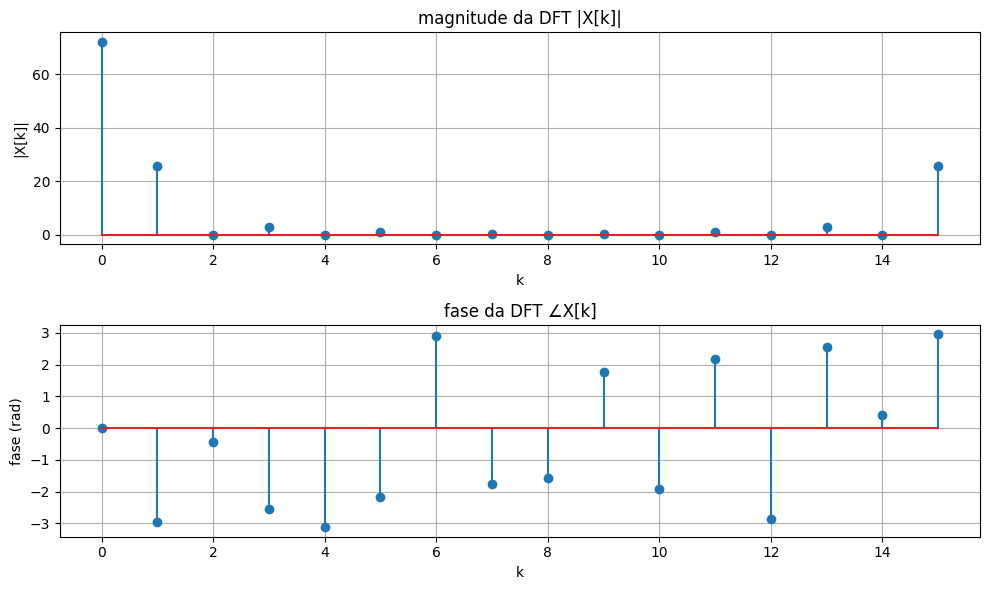

valores da DFT:
  X[0] = 72.0000+0.0000j
  X[1] = -25.2741-5.0273j
  X[2] = 0.0000-0.0000j
  X[3] = -2.2398-1.4966j
  X[4] = -0.0000-0.0000j
  X[5] = -0.4465-0.6682j
  X[6] = -0.0000+0.0000j
  X[7] = -0.0396-0.1989j
  X[8] = 0.0000-0.0000j
  X[9] = -0.0396+0.1989j
  X[10] = -0.0000-0.0000j
  X[11] = -0.4465+0.6682j
  X[12] = -0.0000-0.0000j
  X[13] = -2.2398+1.4966j
  X[14] = 0.0000+0.0000j
  X[15] = -25.2741+5.0273j


In [ ]:
# resposta da questao 1a

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 6, 5, 4, 3, 2, 1], dtype=float)
N = len(x)

X = dft(x)

# plot magnitude e fase
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.stem(range(N), np.abs(X))
ax1.set_title('magnitude da DFT |X[k]|')
ax1.set_xlabel('k')
ax1.set_ylabel('|X[k]|')
ax1.grid(True)

ax2.stem(range(N), np.angle(X))
ax2.set_title('fase da DFT ∠X[k]')
ax2.set_xlabel('k')
ax2.set_ylabel('fase (rad)')
ax2.grid(True)

plt.tight_layout()
plt.show()

print('valores da DFT:')
for k in range(N):
    print(f'  X[{k}] = {X[k]:.4f}')

## Questão 1b (1.0 ponto)

Considere a separação do sinal $x\left[n\right]$ em suas amostras pares e ímpares, $x_e\left[n\right]$ e $x_o\left[n\right]$, respectivamente.

Calcule a DFT do sinal $x\left[n\right]$ através da equação:

$$
\hat{X}\left[k\right] = X_e\left[k\right] + W_{N}^{k} X_o\left[k\right]
$$

Compare as duas DFTs e calcule o erro médio absoluto (MAE) entre as DFTs calculadas pelas duas formas:

$$
MAE = \sum_{i = 0}^{N-1} \left| X\left[i\right] - \hat{X}\left[i\right]\right|
$$

MAE entre X[k] e X_hat[k]: 4.11e-13
(erro praticamente zero, so arredondamento numerico)


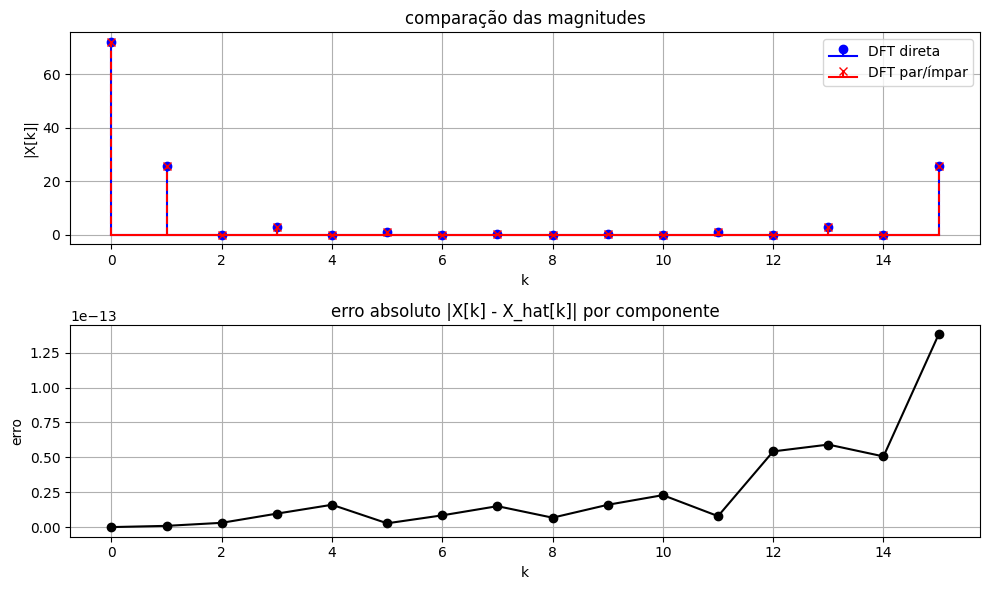

In [ ]:
# resposta da questao 1b

# separa em amostras pares e impares
x_e = x[0::2] # indices pares
x_o = x[1::2] # indices impares
N_half = N // 2

# calcula dft das subsequencias (tamanho N/2)
X_e = dft(x_e)
X_o = dft(x_o)


# X_e e X_o tem periodo N/2, entao usa modulo pra estender
X_hat = np.zeros(N, dtype=complex)
for k in range(N):
    W_N_k = np.exp(-1j * 2 * np.pi * k / N)
    X_hat[k] = X_e[k % N_half] + W_N_k * X_o[k % N_half]

# erro medio absoluto
MAE = np.sum(np.abs(X - X_hat))
print(f'MAE entre X[k] e X_hat[k]: {MAE:.2e}')
print('(erro praticamente zero, so arredondamento numerico)')

# plota pra comparar visualmente
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.stem(range(N), np.abs(X), linefmt='b-', markerfmt='bo', basefmt='b-', label='DFT direta')
ax1.stem(range(N), np.abs(X_hat), linefmt='r--', markerfmt='rx', basefmt='r-', label='DFT par/ímpar')
ax1.set_title('comparação das magnitudes')
ax1.set_xlabel('k')
ax1.set_ylabel('|X[k]|')
ax1.legend()
ax1.grid(True)

ax2.plot(range(N), np.abs(X - X_hat), 'ko-')
ax2.set_title('erro absoluto |X[k] - X_hat[k]| por componente')
ax2.set_xlabel('k')
ax2.set_ylabel('erro')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Questão 2

O arquivo "potencia.txt" contém dados da envoltória real de um tom senoidal amostrado a uma taxa de $200$ amostras / segundo. Para a separação do desvanecimento em larga escala é necessário filtrar esse sinal com um filtro passa-baixas com frequência de corte em torno de $5$ Hz.


## Questão 2a (1.0  ponto)

Projete um filtro digital com a especificação desejada. Podem ser utilizadas as funções de design de filtro da PySDR (https://pysdr.org/content/filters.html), da própria biblioteca scipy (https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) ou mesmo bibliotecas web (http://t-filter.engineerjs.com/) . Plote a resposta em frequência e a resposta ao impulso do filtro projetado.

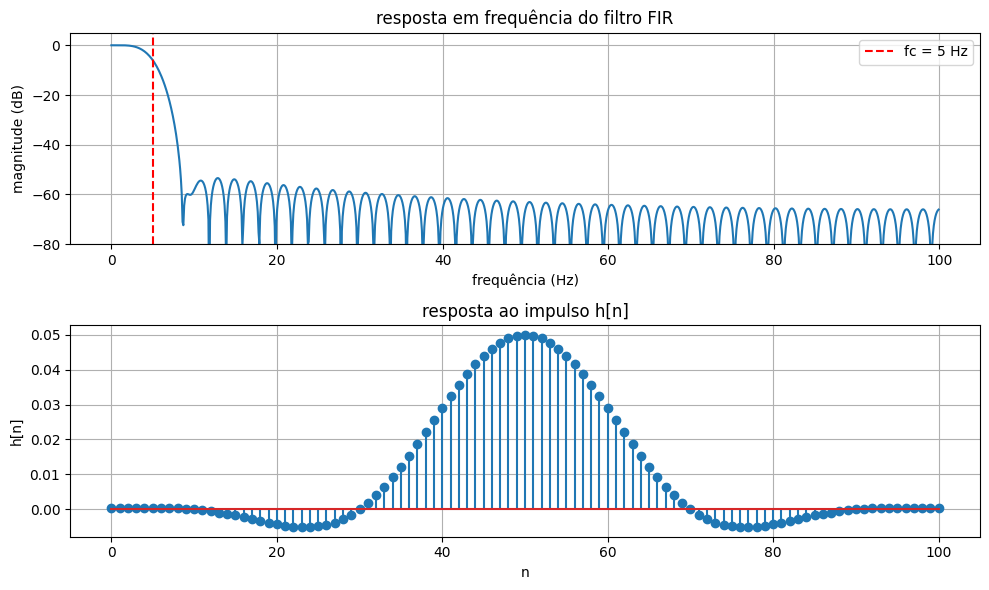

In [ ]:
# resposta da questao 2a

fs = 200   # taxa de amostragem em Hz
fc = 5     # frequencia de corte em Hz

# projeta filtro fir passa-baixas com firwin do scipy
num_taps = 101
h_fir = signal.firwin(num_taps, fc, fs=fs, pass_zero='lowpass')

# resposta em frequencia
w, H_resp = signal.freqz(h_fir, 1.0, worN=1024, fs=fs)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# magnitude em dB
ax1.plot(w, 20 * np.log10(np.abs(H_resp) + 1e-12))
ax1.axvline(fc, color='r', linestyle='--', label=f'fc = {fc} Hz')
ax1.set_title('resposta em frequência do filtro FIR')
ax1.set_xlabel('frequência (Hz)')
ax1.set_ylabel('magnitude (dB)')
ax1.set_ylim([-80, 5])
ax1.legend()
ax1.grid(True)

# resposta ao impulso
ax2.stem(range(num_taps), h_fir)
ax2.set_title('resposta ao impulso h[n]')
ax2.set_xlabel('n')
ax2.set_ylabel('h[n]')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Questão 2b (1.0 ponto)

Escreva uma função para processar uma janela de $N$ amostras do sinal desejado. $N$ deve ser escolhido em torno de 1 segundo de sinal, aproximadamente. A filtragem deve ser feita no domínio da DFT (pode ser utilizada alguma função para cálculo da fft em Python, como a função fft da biblioteca numpy).

tamanho da janela: L = 200 amostras (1.0 s)
tamanho do filtro: M = 101 taps
tamanho da fft: N = L + M - 1 = 300


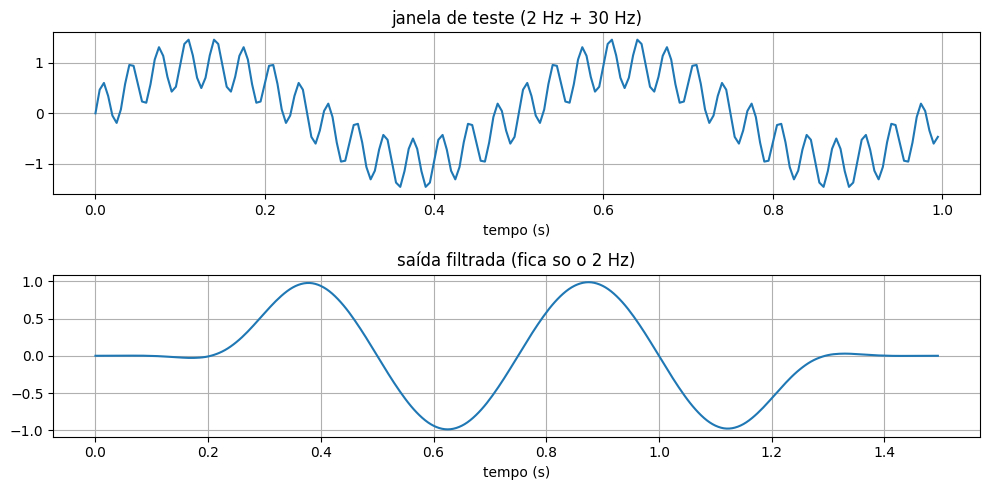

In [ ]:
# resposta da questao 2b


# parametros escolhidos:
# L = 200 amostras
# N_fft = L + M - 1 pra evitar aliasing circular
L = 200
M = len(h_fir)
N_fft = L + M - 1
print(f'tamanho da janela: L = {L} amostras ({L/fs:.1f} s)')
print(f'tamanho do filtro: M = {M} taps')
print(f'tamanho da fft: N = L + M - 1 = {N_fft}')

# teste rapido com sinal sintetico: 2 Hz (passa) + 30 Hz (nao passa)
t_teste = np.arange(L) / fs
sinal_teste = np.sin(2 * np.pi * 2 * t_teste) + 0.5 * np.sin(2 * np.pi * 30 * t_teste)
y_teste = filtra_janela(sinal_teste, h_fir, N_fft)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))
ax1.plot(t_teste, sinal_teste)
ax1.set_title('janela de teste (2 Hz + 30 Hz)')
ax1.set_xlabel('tempo (s)')
ax1.grid(True)

ax2.plot(np.arange(len(y_teste)) / fs, y_teste)
ax2.set_title('saída filtrada (fica so o 2 Hz)')
ax2.set_xlabel('tempo (s)')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Questão 2c (1.0  ponto)

Escreva uma função para combinar a saída do processamento de cada janela na saída do sistema, utilizando **um** dos métodos vistos (*overlap and add* ou *overlap and save*). Indique claramente o método escolhido.


In [ ]:
# resposta da questao 2c

# metodo escolhido: overlap and add
sinal = np.loadtxt("potencia.txt")

# aplica overlap-and-add no sinal completo
L = 200
y_ola = overlap_add(sinal, h_fir, L)

print(f'sinal de entrada: {len(sinal)} amostras ({len(sinal)/fs:.1f} s)')
print(f'tamanho do bloco: {L} amostras ({L/fs:.1f} s)')
print(f'numero de blocos: {int(np.ceil(len(sinal)/L))}')
print(f'saida: {len(y_ola)} amostras')

sinal de entrada: 8001 amostras (40.0 s)
tamanho do bloco: 200 amostras (1.0 s)
numero de blocos: 41
saida: 8001 amostras


## Questão 2d (1.0  ponto)

Plote o sinal de entrada e saída do sistema dado tanto pelo processamento em janelas como pelo processamento do sinal completo. Pode ser utilizada alguma função da biblioteca do python para calcular a saída do sistema usando o sinal completo.

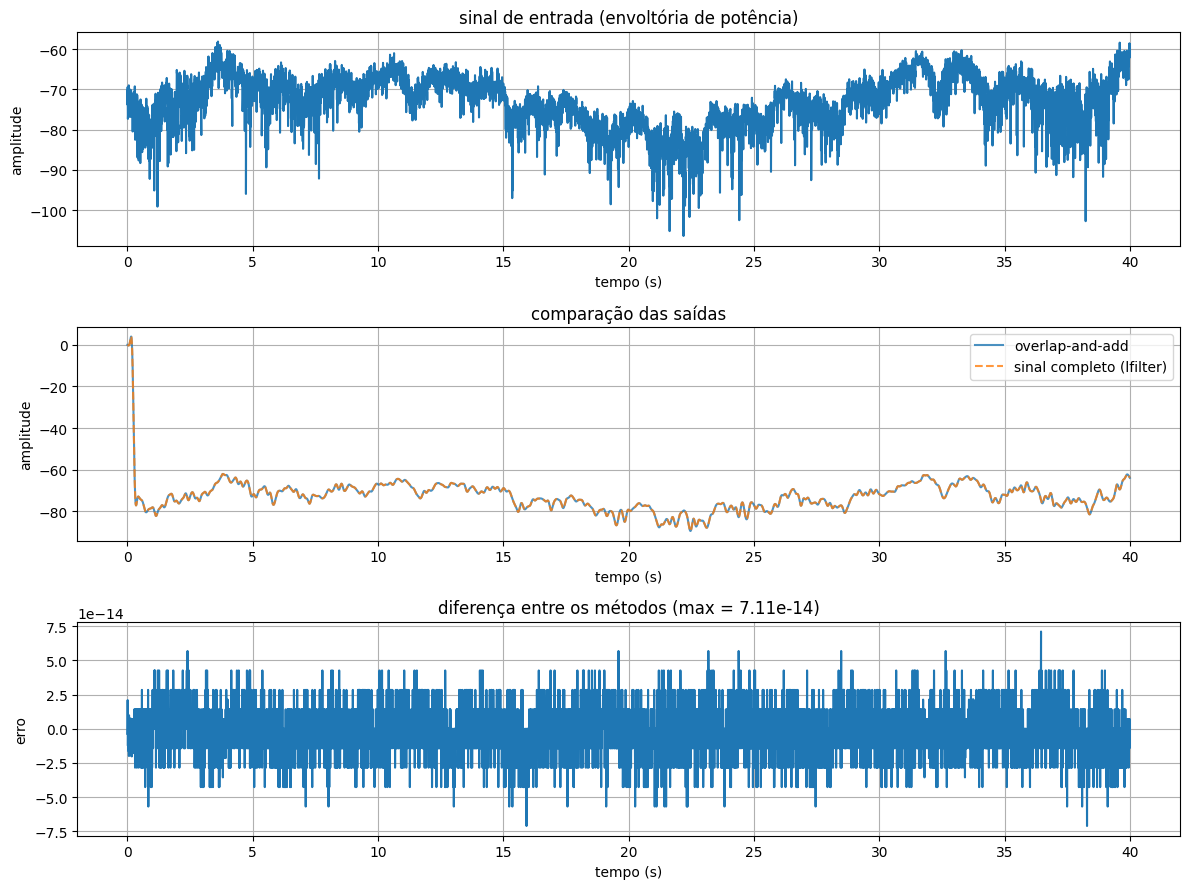

erro maximo entre os metodos: 7.11e-14
os dois metodos dao essencialmente o mesmo resultado


In [ ]:
# resposta da questao 2d

# filtra o sinal inteiro de uma vez usando lfilter pra comparar
y_completo = signal.lfilter(h_fir, 1.0, sinal)

t = np.arange(len(sinal)) / fs

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

# sinal de entrada
axes[0].plot(t, sinal)
axes[0].set_title('sinal de entrada (envoltória de potência)')
axes[0].set_xlabel('tempo (s)')
axes[0].set_ylabel('amplitude')
axes[0].grid(True)

# saidas sobrepostas
axes[1].plot(t, y_ola, label='overlap-and-add', alpha=0.8)
axes[1].plot(t, y_completo, '--', label='sinal completo (lfilter)', alpha=0.8)
axes[1].set_title('comparação das saídas')
axes[1].set_xlabel('tempo (s)')
axes[1].set_ylabel('amplitude')
axes[1].legend()
axes[1].grid(True)

# diferença entre os metodos
erro = y_ola - y_completo
axes[2].plot(t, erro)
axes[2].set_title(f'diferença entre os métodos (max = {np.max(np.abs(erro)):.2e})')
axes[2].set_xlabel('tempo (s)')
axes[2].set_ylabel('erro')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f'erro maximo entre os metodos: {np.max(np.abs(erro)):.2e}')
print('os dois metodos dao essencialmente o mesmo resultado')

# Questão 3

A equação diferença para um filtro FIR de tamanho $N$ pode ser escrita como:

$$
\begin{align}
	y\left[n\right] &= h_0 x\left[n\right] + h_1 x\left[n-1\right] + h_2 x\left[n-2\right] + h_3 \left[n-3\right] + \ldots + h_{N-1} x\left[n - \left(N- 1\right)\right] \\
	       &= \sum_{k=0}^{N-1} h_k x\left[n - k\right]
\end{align}
$$

Os coeficientes do filtro, ou \textit{taps}, são expressados usando a variável $h_k$ para enfatizar que os próprios coeficientes representam a resposta ao impulso do filtro. A resposta em frequência do filtro é:

$$
\begin{align}
	H\left( \Omega \right) = \frac{Y\left( \Omega \right)}{X\left( \Omega \right)} = \sum_{k=0}^{N-1} h_k e^{-j \Omega k}
\end{align}
$$

Como $H\left( \Omega \right)$ é uma função com período $2 \pi$ da variável contínua $\Omega$, é suficiente especificar $H\left( \Omega \right)$ em apenas um período $0 \leq \Omega < 2 \pi$.

Em muitas aplicações, a resposta em magnitude desejada do filtro $\left|H_d \left( \Omega \right)\right|$ é conhecida, mas não os coeficientes $h_k$ do filtro. A questão é, então, determinar os coeficientes do filtro a partir da resposta em magnitude desejada. Podemos fazer isso simplesmente amostrando a resposta em frequência desejada $\left|H_d \left( \Omega \right)\right|$ com $N$ amostras em um período, e então fazendo a DFT inversa dessas amostras (obtendo $h\left[n\right]$). Note que a definição dos coeficientes $h_k$ é suficiente para determinar o sistema do filtro FIR. Além disso, como $H \left( \Omega \right)$ foi obtido amostrando $\left|H_d \left( \Omega \right)\right|$ para algumas frequências, garantimos que a resposta em frequência do filtro projeto será igual a resposta em frequência desejada ao menos nos valores de amostragem. Finalmente, observe que, ao fazer a DFT inversa, alguns coeficientes $h_k$ podem ter uma pequena componente imaginária que deve ser descartada para o projeto de um filtro real.



## Questão 3a (1.0  ponto)

Considere então um sinal de ECG amostrado a uma taxa de $500$ Hz. Projete um filtro digital FIR através da amostragem de frequência passa-baixas com frequência de corte igual a $50$ Hz.

Plote a resposta ao impulso $h\left[n\right]$ e a resposta em frequência $H\left(\Omega\right)$ do filtro para $N = 21$, $N = 31$ e $N = 41$. Compare os filtros com a resposta em frequência desejada.

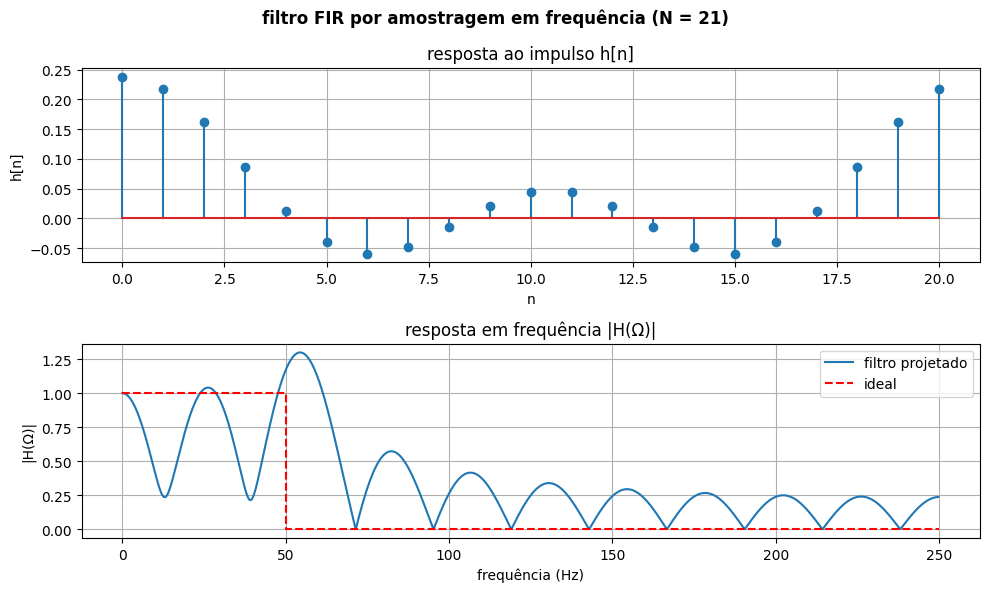

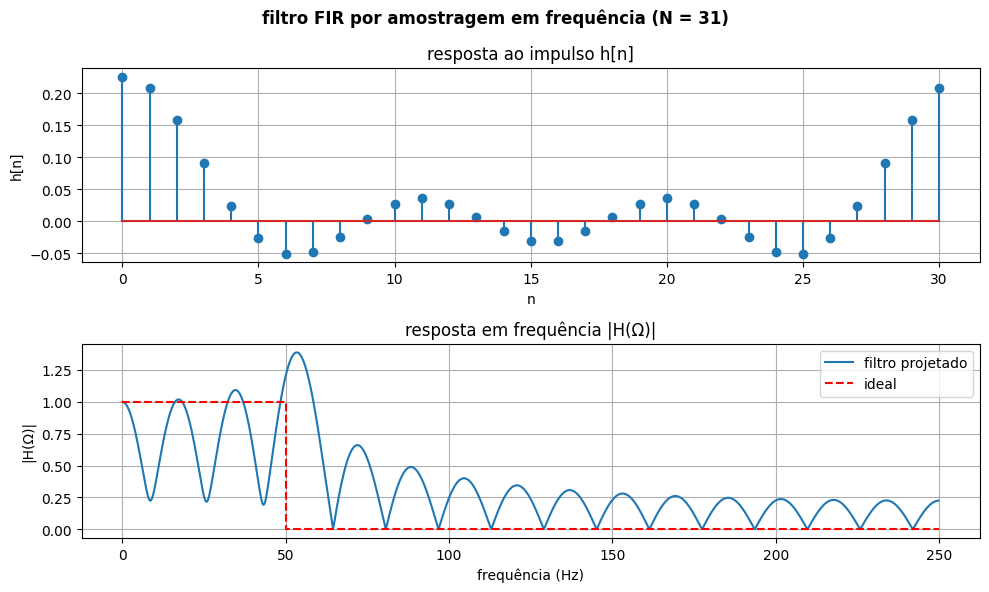

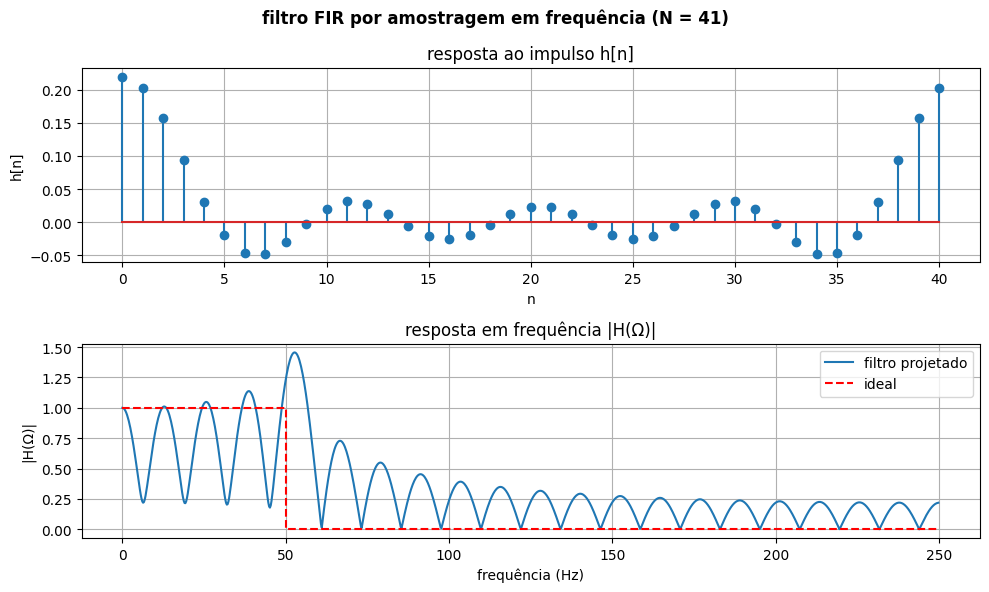

In [ ]:
# resposta da questao 3a

fs_ecg = 500   # taxa de amostragem em Hz
fc_ecg = 50    # frequencia de corte em Hz

# guarda os filtros pra comparar com os da 3b
filtros_q3a = {}

for N_filt in [21, 31, 41]:
    # amostra a resposta em frequencia ideal do passa-baixas
    H_d = np.zeros(N_filt)
    for k in range(N_filt):
        f_k = k * fs_ecg / N_filt
        # passa-baixas ideal: H=1 se f <= fc, e pela simetria, se f >= fs-fc
        if f_k <= fc_ecg or f_k >= (fs_ecg - fc_ecg):
            H_d[k] = 1.0

    # idft pra pegar os coeficientes h[n]
    h_n = np.fft.ifft(H_d).real
    filtros_q3a[N_filt] = h_n

    # resposta em frequencia do filtro projetado
    w_f, H_proj = signal.freqz(h_n, 1.0, worN=1024, fs=fs_ecg)

    # plota
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
    fig.suptitle(f'filtro FIR por amostragem em frequência (N = {N_filt})', fontweight='bold')

    # resposta ao impulso
    ax1.stem(range(N_filt), h_n)
    ax1.set_title('resposta ao impulso h[n]')
    ax1.set_xlabel('n')
    ax1.set_ylabel('h[n]')
    ax1.grid(True)

    # resposta em frequencia vs ideal
    ax2.plot(w_f, np.abs(H_proj), label='filtro projetado')
    ax2.plot([0, fc_ecg, fc_ecg, fs_ecg/2], [1, 1, 0, 0], 'r--', label='ideal')
    ax2.set_title('resposta em frequência |H(Ω)|')
    ax2.set_xlabel('frequência (Hz)')
    ax2.set_ylabel('|H(Ω)|')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

## Questão 3b (1.0  ponto)

A resposta ao impulso do filtro do item anterior deveria ser uma função *sinc*, que é uma função com suporte infinito. Porém, a amostragem amostra apenas a parte para $n$ positivo, gerando uma descontinuidade e uma resposta em frequência mais pobre. Uma forma de melhorar essa amostragem é centralizar a função *sinc* - para isso, devemos multiplicar a resposta em frequência do filtro $H\left(\Omega\right)$ por $e^{-j \Omega \frac{\left(N - 1\right)}{2}}$. Utilize essa técnica para gerar novos filtros com $N = 21$, $N = 31$ e $N = 41$. Compare os filtros com os filtros do item anterior com o mesmo tamanho.

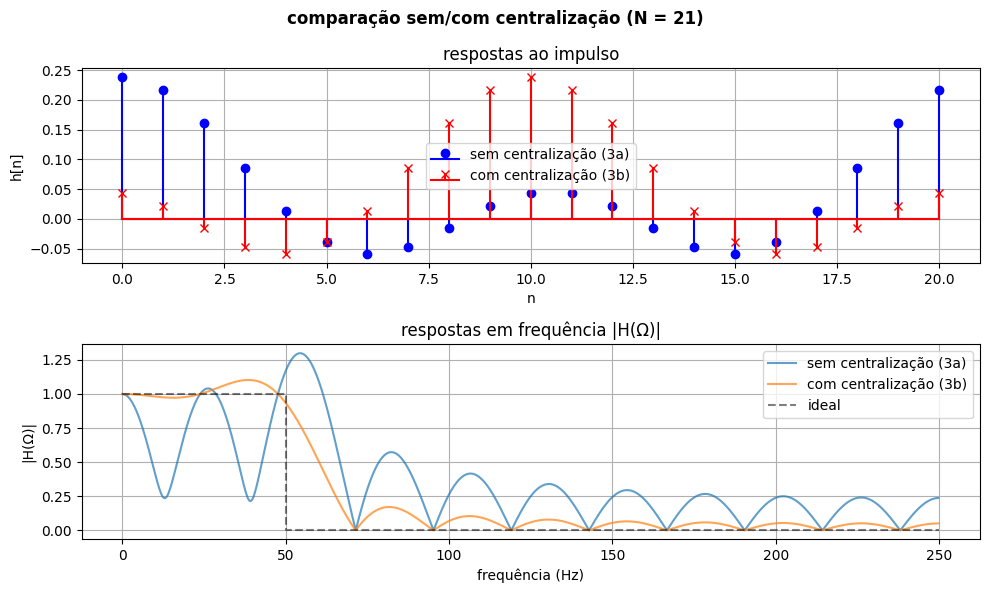

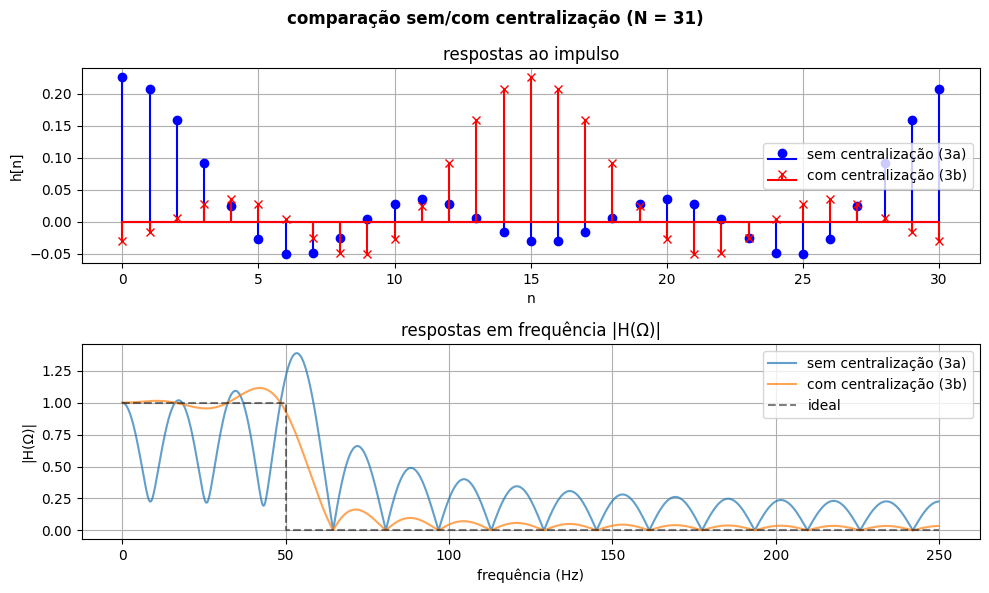

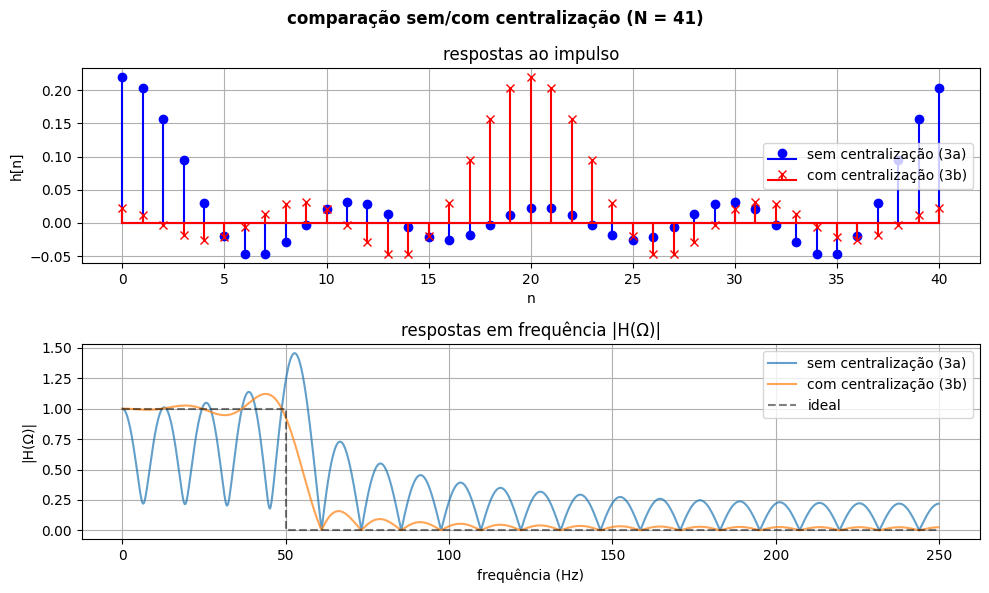

In [ ]:
# resposta da questao 3b

# guarda os filtros centralizados
filtros_q3b = {}

for N_filt in [21, 31, 41]:
    # mesma amostragem, mas agora com o phase shift pra centralizar a sinc
    H_d_cent = np.zeros(N_filt, dtype=complex)
    for k in range(N_filt):
        f_k = k * fs_ecg / N_filt
        Omega_k = 2 * np.pi * k / N_filt
        if f_k <= fc_ecg or f_k >= (fs_ecg - fc_ecg):
            # multiplica pelo fator de centralização e^(-jΩ(N-1)/2)
            H_d_cent[k] = np.exp(-1j * Omega_k * (N_filt - 1) / 2)

    # idft -> agora h[n] parece uma sinc centralizada
    h_cent = np.fft.ifft(H_d_cent).real
    filtros_q3b[N_filt] = h_cent

    # respostas em frequencia pra comparar
    w_f, H_cent_resp = signal.freqz(h_cent, 1.0, worN=1024, fs=fs_ecg)
    _, H_ant_resp = signal.freqz(filtros_q3a[N_filt], 1.0, worN=1024, fs=fs_ecg)

    # plota comparando com o filtro do item anterior
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
    fig.suptitle(f'comparação sem/com centralização (N = {N_filt})', fontweight='bold')

    # respostas ao impulso
    ax1.stem(range(N_filt), filtros_q3a[N_filt], linefmt='b-', markerfmt='bo',
             basefmt='b-', label='sem centralização (3a)')
    ax1.stem(range(N_filt), h_cent, linefmt='r-', markerfmt='rx',
             basefmt='r-', label='com centralização (3b)')
    ax1.set_title('respostas ao impulso')
    ax1.set_xlabel('n')
    ax1.set_ylabel('h[n]')
    ax1.legend()
    ax1.grid(True)

    # respostas em frequencia
    ax2.plot(w_f, np.abs(H_ant_resp), label='sem centralização (3a)', alpha=0.7)
    ax2.plot(w_f, np.abs(H_cent_resp), label='com centralização (3b)', alpha=0.7)
    ax2.plot([0, fc_ecg, fc_ecg, fs_ecg/2], [1, 1, 0, 0], 'k--', label='ideal', alpha=0.5)
    ax2.set_title('respostas em frequência |H(Ω)|')
    ax2.set_xlabel('frequência (Hz)')
    ax2.set_ylabel('|H(Ω)|')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

## Questão 3c (1.0  ponto)

Aplique o filtro com $N = 41$ no sinal do arquivo "noisy\_ecg\_data\_3.mat". Compare o sinal de entrada com o sinal de saída. O que acontece com os picos do ECG?

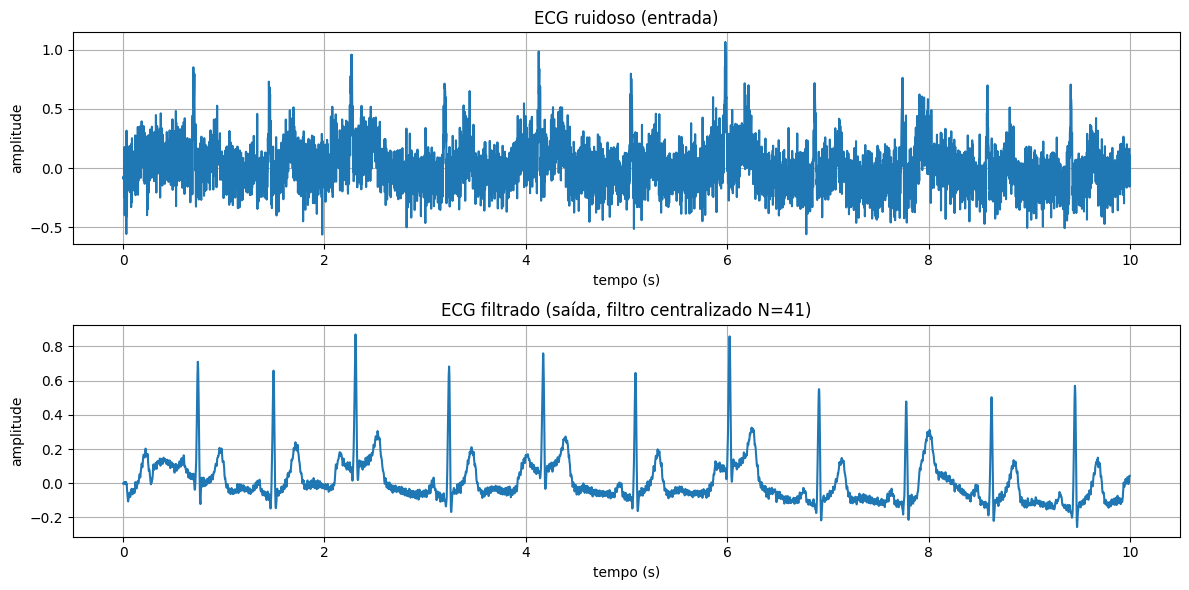

os picos R do ECG ficam atenuados e mais suaves porque o filtro
remove as altas frequências que compõem os picos agudos do QRS.
há tambem um atraso de grupo de 20 amostras (40 ms), deslocando os picos.


In [ ]:
# resposta da questao 3c

sinal_ecg = sp.io.loadmat('noisy_ecg_data_3.mat')['noisy_ecg_3'].ravel()

h_41 = filtros_q3b[41]

y_ecg = signal.lfilter(h_41, 1.0, sinal_ecg)

# plota
t_ecg = np.arange(len(sinal_ecg)) / fs_ecg

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(t_ecg, sinal_ecg)
ax1.set_title('ECG ruidoso (entrada)')
ax1.set_xlabel('tempo (s)')
ax1.set_ylabel('amplitude')
ax1.grid(True)

ax2.plot(t_ecg, y_ecg)
ax2.set_title('ECG filtrado (saída, filtro centralizado N=41)')
ax2.set_xlabel('tempo (s)')
ax2.set_ylabel('amplitude')
ax2.grid(True)

plt.tight_layout()
plt.show()

print('os picos R do ECG ficam atenuados e mais suaves porque o filtro')
print('remove as altas frequências que compõem os picos agudos do QRS.')
print(f'há tambem um atraso de grupo de {(len(h_41)-1)//2} amostras '
      f'({(len(h_41)-1)/2/fs_ecg*1000:.0f} ms), deslocando os picos.')

## Questão 3d (1.0  ponto)

Utilize a técnica de *zero-phase filtering* com o filtro do item anterior. Compare a saída do sistema com e sem a aplicação da técnica.

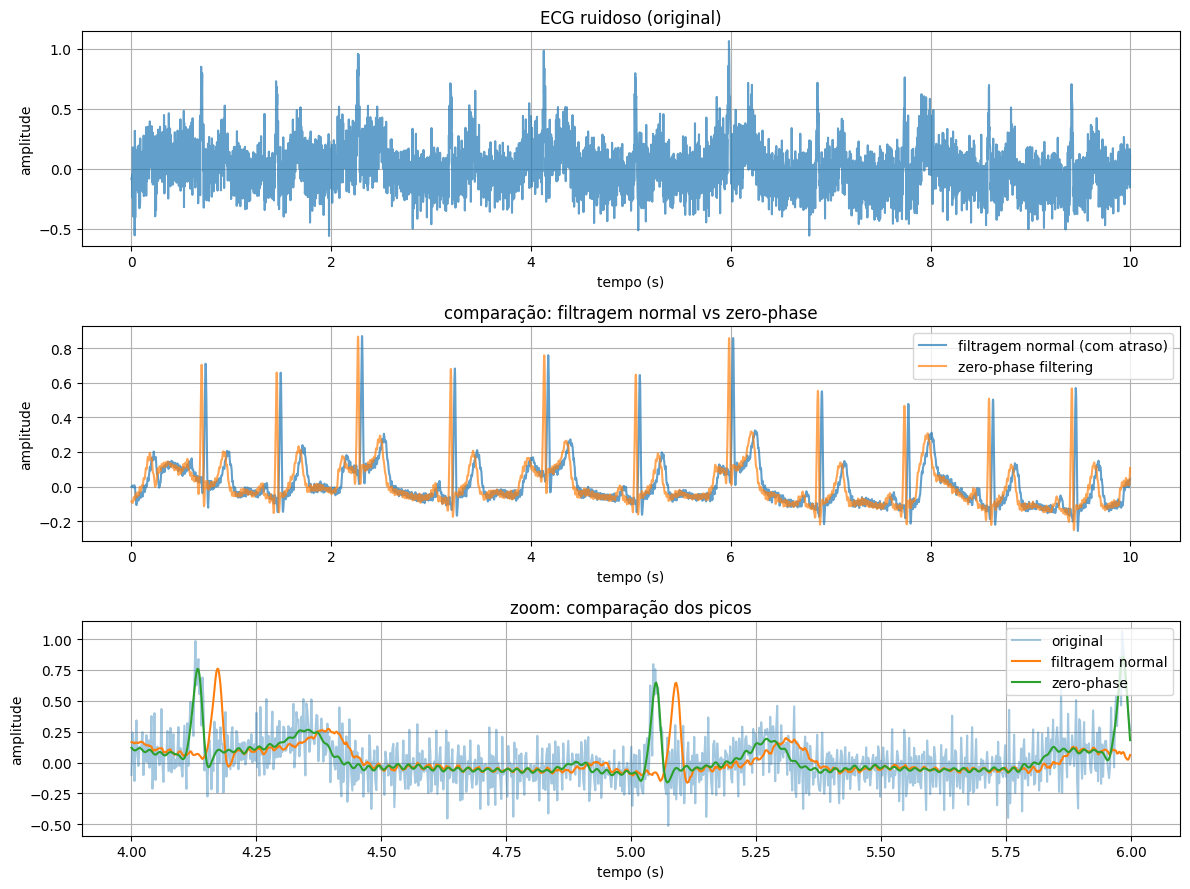

In [ ]:
# resposta da questao 3d


y_zerophase = signal.filtfilt(h_41, 1.0, sinal_ecg)

# filtragem normal
y_normal = signal.lfilter(h_41, 1.0, sinal_ecg)

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

axes[0].plot(t_ecg, sinal_ecg, alpha=0.7)
axes[0].set_title('ECG ruidoso (original)')
axes[0].set_xlabel('tempo (s)')
axes[0].set_ylabel('amplitude')
axes[0].grid(True)

axes[1].plot(t_ecg, y_normal, label='filtragem normal (com atraso)', alpha=0.7)
axes[1].plot(t_ecg, y_zerophase, label='zero-phase filtering', alpha=0.7)
axes[1].set_title('comparação: filtragem normal vs zero-phase')
axes[1].set_xlabel('tempo (s)')
axes[1].set_ylabel('amplitude')
axes[1].legend()
axes[1].grid(True)

# zoom no trecho do meio pra ver a diferença nos picos
meio = len(sinal_ecg) // 2
ini_zoom = meio - fs_ecg
fim_zoom = meio + fs_ecg
t_zoom = t_ecg[ini_zoom:fim_zoom]

axes[2].plot(t_zoom, sinal_ecg[ini_zoom:fim_zoom], alpha=0.4, label='original')
axes[2].plot(t_zoom, y_normal[ini_zoom:fim_zoom], label='filtragem normal')
axes[2].plot(t_zoom, y_zerophase[ini_zoom:fim_zoom], label='zero-phase')
axes[2].set_title('zoom: comparação dos picos')
axes[2].set_xlabel('tempo (s)')
axes[2].set_ylabel('amplitude')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()
